# 04. PSD/P80 from exterior surface-size proxy

Convex hull volume is not valid for exterior-only partial scans. This notebook estimates PSD from robust surface-size proxies and compares the result against the Synthetic_Rockpile ground-truth PSD.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.fragmentation.surface_proxy import estimate_surface_size_proxy
from src.fragmentation.psd import cumulative_psd, percentile_size

SEG_PATH = PROJECT_ROOT / 'data' / 'labels' / 'synthetic_rockpile_exterior_surface_segmentation.npz'
GT_PSD_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'ground_truth_psd.csv'
GT_SUMMARY_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'ground_truth_summary.csv'
SIZE_TABLE_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'surface_proxy_cluster_sizes.csv'
PSD_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'estimated_psd_surface_proxy.csv'
COMPARE_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'surface_proxy_p80_comparison.csv'
FIG_PATH = PROJECT_ROOT / 'outputs' / 'figures' / 'surface_proxy_psd_vs_ground_truth.png'
SIZE_TABLE_PATH.parent.mkdir(parents=True, exist_ok=True)
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)

In [2]:
data = np.load(SEG_PATH)
points = data['points_xyz']
labels_surface = data['labels_surface']
size_df = estimate_surface_size_proxy(points, labels_surface, min_points=10, pairwise_percentile=90.0)
size_df.to_csv(SIZE_TABLE_PATH, index=False)
psd_surface = cumulative_psd(size_df['diameter_proxy_m'].to_numpy(), size_df['proxy_volume_m3'].to_numpy())
psd_surface.to_csv(PSD_PATH, index=False)
size_df.head(), psd_surface.tail()

(   cluster_id  n_points  diameter_proxy_m  diameter_proxy_mm  pca_span_1_m  \
 0           0        25          0.082754          82.753926      0.082754   
 1           1        22          0.105440         105.439946      0.105440   
 2           2        26          0.078209          78.208840      0.078209   
 3           3        45          0.212829         212.828770      0.212829   
 4           4        28          0.089060          89.059967      0.089060   
 
    pca_span_2_m  pca_span_3_m  pairwise_d90_m  proxy_volume_m3  
 0      0.069267      0.026103        0.069312         0.000297  
 1      0.073790      0.022164        0.085545         0.000614  
 2      0.074902      0.025721        0.067550         0.000250  
 3      0.114848      0.050254        0.140367         0.005048  
 4      0.078448      0.042942        0.081158         0.000370  ,
      diameter_m  diameter_mm  volume_m3  volume_fraction  \
 555    0.362315   362.315140   0.024903         0.016093   
 556 

In [3]:
gt_psd = pd.read_csv(GT_PSD_PATH)
if 'diameter_mm' not in gt_psd.columns and 'diameter_from_volume_mm' in gt_psd.columns:
    gt_psd = gt_psd.rename(columns={'diameter_from_volume_mm': 'diameter_mm'})
if 'diameter_m' not in gt_psd.columns:
    gt_psd['diameter_m'] = gt_psd['diameter_mm'] / 1000.0
if 'cumulative_passing_pct' not in gt_psd.columns and 'cumulative_passing_percent' in gt_psd.columns:
    gt_psd = gt_psd.rename(columns={'cumulative_passing_percent': 'cumulative_passing_pct'})

gt_summary = pd.read_csv(GT_SUMMARY_PATH)
gt_p80 = float(gt_summary['P80_mm'].iloc[0]) if 'P80_mm' in gt_summary.columns else float(np.interp(80, gt_psd['cumulative_passing_pct'], gt_psd['diameter_mm']))
proxy_p10 = percentile_size(psd_surface, 10)
proxy_p50 = percentile_size(psd_surface, 50)
proxy_p80 = percentile_size(psd_surface, 80)
comparison = pd.DataFrame([
    {
        'method': 'surface_geometry_proxy',
        'n_estimated_fragments': int(len(size_df)),
        'ground_truth_P80_mm': gt_p80,
        'estimated_P10_mm': proxy_p10,
        'estimated_P50_mm': proxy_p50,
        'estimated_P80_mm': proxy_p80,
        'P80_error_mm': proxy_p80 - gt_p80,
        'P80_relative_error_pct': 100.0 * (proxy_p80 - gt_p80) / gt_p80,
    }
])
comparison.to_csv(COMPARE_PATH, index=False)
comparison

,method,n_estimated_fragments,ground_truth_P80_mm,estimated_P10_mm,estimated_P50_mm,estimated_P80_mm,P80_error_mm,P80_relative_error_pct
0,surface_geometry_proxy,560,265.185122,130.591069,237.79647,340.282797,75.097676,28.318963


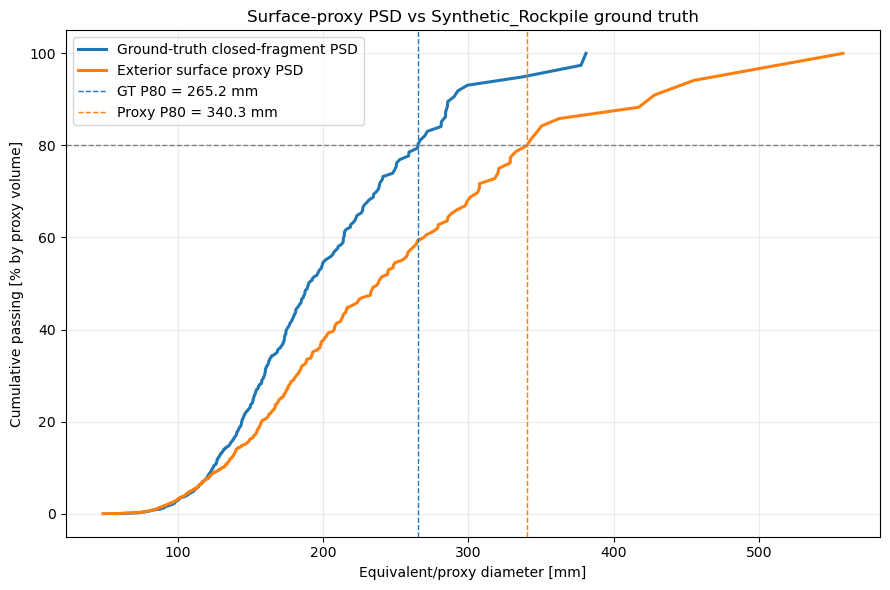

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(gt_psd['diameter_mm'], gt_psd['cumulative_passing_pct'], lw=2.2, label='Ground-truth closed-fragment PSD')
ax.plot(psd_surface['diameter_mm'], psd_surface['cumulative_passing_pct'], lw=2.2, label='Exterior surface proxy PSD')
ax.axhline(80, ls='--', color='tab:gray', lw=1)
ax.axvline(gt_p80, ls='--', color='tab:blue', lw=1, label=f'GT P80 = {gt_p80:.1f} mm')
ax.axvline(proxy_p80, ls='--', color='tab:orange', lw=1, label=f'Proxy P80 = {proxy_p80:.1f} mm')
ax.set_title('Surface-proxy PSD vs Synthetic_Rockpile ground truth')
ax.set_xlabel('Equivalent/proxy diameter [mm]')
ax.set_ylabel('Cumulative passing [% by proxy volume]')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=180)
plt.show()

## Interpretation

The surface-proxy result is a benchmark estimate from visible geometry, not a recovered closed-mesh volume. A large residual P80 error usually indicates merged visible surface patches, missed occluded fragments, or an insufficient size-to-volume calibration model.